# IDC Baseline Improvement Experiment

This notebook runs a controlled improvement experiment on the custom baseline CNN.

What changes relative to the original baseline:
- train-split mean/std normalization
- light color jitter during training only
- `ReduceLROnPlateau` learning-rate scheduler

Workflow:
- mount Google Drive
- reuse the cached dataset zip from Drive
- extract the dataset into `/content`
- estimate train-split normalization statistics
- train the same custom CNN with the controlled improvements
- save the best checkpoint, history, and metrics


In [6]:
from google.colab import drive
from pathlib import Path
import sys

drive.mount('/content/drive')

# Notebook 04 keeps the same CNN architecture and only improves preprocessing/training behavior.
PROJECT_ROOT = Path('/content/drive/MyDrive/Workshop UDL')
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATASET_ARCHIVE_PATH = PROJECT_ROOT / 'datasets' / 'Breast Cancer Histopathology Dataset.zip'
TRAINING_RUNS_DIR = PROJECT_ROOT / 'training_runs'

RUNTIME_DIR = Path('/content/idc_runtime')
RUNTIME_EXTRACT_DIR = RUNTIME_DIR / 'dataset'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f'Source directory not found: {SRC_DIR}. '
        'Put the project folder in Google Drive so Colab can import src/idc_pipeline.'
    )

print(f'Project root: {PROJECT_ROOT}')
print(f'Artifacts dir: {ARTIFACTS_DIR}')
print(f'Dataset archive cache: {DATASET_ARCHIVE_PATH}')
print(f'Training runs dir: {TRAINING_RUNS_DIR}')
print(f'Runtime extract dir: {RUNTIME_EXTRACT_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Workshop UDL
Artifacts dir: /content/drive/MyDrive/Workshop UDL/artifacts
Dataset archive cache: /content/drive/MyDrive/Workshop UDL/datasets/Breast Cancer Histopathology Dataset.zip
Training runs dir: /content/drive/MyDrive/Workshop UDL/training_runs
Runtime extract dir: /content/idc_runtime/dataset


In [7]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from idc_pipeline.dataset import compute_dataset_normalization
from idc_pipeline.download import prepare_dataset_from_cached_zip
from idc_pipeline.train import TrainingConfig, run_training_experiment

required_artifacts = [
    ARTIFACTS_DIR / 'cleaning_summary.json',
    ARTIFACTS_DIR / 'splits' / 'train.csv',
    ARTIFACTS_DIR / 'splits' / 'val.csv',
    ARTIFACTS_DIR / 'splits' / 'test.csv',
]
missing_artifacts = [path for path in required_artifacts if not path.exists()]
if missing_artifacts:
    missing_text = '\n'.join(str(path) for path in missing_artifacts)
    raise FileNotFoundError(
        'Missing cleaned split artifacts. Run notebook 01 first.\n'
        f'Missing files:\n{missing_text}'
    )

dataset_dir = prepare_dataset_from_cached_zip(
    archive_path=DATASET_ARCHIVE_PATH,
    extract_dir=RUNTIME_EXTRACT_DIR,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dataset ready at: {dataset_dir}')
print(f'PyTorch device: {device}')


Using existing extracted dataset: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Resolved canonical dataset directory: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Dataset ready at: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
PyTorch device: cuda


In [8]:
train_csv_path = ARTIFACTS_DIR / 'splits' / 'train.csv'
val_csv_path = ARTIFACTS_DIR / 'splits' / 'val.csv'
test_csv_path = ARTIFACTS_DIR / 'splits' / 'test.csv'

# This run adds train-split normalization, light color jitter, and a scheduler.
run_name = 'baseline_cnn_improved_seed42'
output_dir = TRAINING_RUNS_DIR / run_name

normalization_sample_limit = None
color_jitter_strength = 0.10

# Mean/std are computed from the training split only to avoid leaking validation/test information.
normalization = compute_dataset_normalization(
    train_csv_path,
    dataset_dir,
    max_samples=normalization_sample_limit,
    seed=42,
)

print('Normalization source:', 'full train split' if normalization_sample_limit is None else f'sampled {normalization_sample_limit:,} patches')
display(pd.DataFrame([{'mean': normalization.mean, 'std': normalization.std}]))

training_config = TrainingConfig(
    batch_size=128,
    epochs=15,
    learning_rate=1e-3,
    weight_decay=1e-4,
    num_workers=2,
    seed=42,
    early_stopping_patience=5,
    threshold=0.5,
    dropout=0.30,
    normalization_mean=normalization.mean,
    normalization_std=normalization.std,
    color_jitter_strength=color_jitter_strength,
    scheduler_name='reduce_on_plateau',
    scheduler_factor=0.5,
    scheduler_patience=1,
    scheduler_min_lr=1e-6,
    selection_metric='roc_auc',
)

result = run_training_experiment(
    dataset_dir=dataset_dir,
    train_csv_path=train_csv_path,
    val_csv_path=val_csv_path,
    test_csv_path=test_csv_path,
    output_dir=output_dir,
    config=training_config,
)

result


Normalization source: full train split


,mean,std
0,"(0.8109254012350998, 0.6303300277897085, 0.730...","(0.1438434784213181, 0.21134512736532152, 0.15..."


Starting training on cuda | architecture=baseline_cnn | normalization=train_stats | color_jitter=0.10 | scheduler=reduce_on_plateau | train=193,281, val=40,963, test=40,978 | pos_weight=2.4828
Epoch 01/15 | 24.8s | lr=0.001000 | train_loss=0.5658 | val_loss=0.5485 | val_acc=0.8095 | val_f1=0.7279 | val_auc=0.9195 | best=yes
Epoch 02/15 | 24.7s | lr=0.001000 | train_loss=0.4942 | val_loss=0.4897 | val_acc=0.8295 | val_f1=0.7491 | val_auc=0.9272 | best=yes
Epoch 03/15 | 24.7s | lr=0.001000 | train_loss=0.4678 | val_loss=0.5030 | val_acc=0.8171 | val_f1=0.7378 | val_auc=0.9236 | best=no
Epoch 04/15 | 24.6s | lr=0.000500 | train_loss=0.4517 | val_loss=0.5648 | val_acc=0.7877 | val_f1=0.7169 | val_auc=0.9327 | best=yes
Epoch 05/15 | 24.6s | lr=0.000500 | train_loss=0.4180 | val_loss=0.5012 | val_acc=0.8682 | val_f1=0.7732 | val_auc=0.9313 | best=no
Epoch 06/15 | 24.7s | lr=0.000500 | train_loss=0.4135 | val_loss=0.4508 | val_acc=0.8531 | val_f1=0.7727 | val_auc=0.9381 | best=yes
Epoch 07/15

TrainingRunResult(output_dir=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42'), checkpoint_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/best_model.pt'), history_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/history.csv'), metrics_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/metrics.json'), config_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/config.json'), best_epoch=13, best_metric_name='roc_auc', best_metric_value=0.9458321350565005, train_summary={'total': 193281, 'positive': 55496, 'negative': 137785}, val_summary={'total': 40963, 'positive': 11523, 'negative': 29440}, test_summary={'total': 40978, 'positive': 11749, 'negative': 29229}, pos_weight=2.4827915525443274, test_metrics={'loss': 0.42289588934762323, 'accuracy': 0.8755185709405047, 'prec

In [9]:
# The output folder structure stays the same as notebook 03 so runs are easy to compare.
print(json.dumps(result.to_dict(), indent=2))

with result.metrics_path.open() as handle:
    metrics_payload = json.load(handle)

history_df = pd.read_csv(result.history_path)
display(history_df)


{
  "output_dir": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42",
  "checkpoint_path": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/best_model.pt",
  "history_path": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/history.csv",
  "metrics_path": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/metrics.json",
  "config_path": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/config.json",
  "best_epoch": 13,
  "best_metric_name": "roc_auc",
  "best_metric_value": 0.9458321350565005,
  "train_summary": {
    "total": 193281,
    "positive": 55496,
    "negative": 137785
  },
  "val_summary": {
    "total": 40963,
    "positive": 11523,
    "negative": 29440
  },
  "test_summary": {
    "total": 40978,
    "positive": 11749,
    "negative": 29229
  },
  "pos_weight": 2.4827915525443274,
  "best_val_metrics": {
    "loss": 0.44544

,epoch,learning_rate,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001000,0.565767,0.827640,0.654063,0.848458,0.738685,0.902501,0.548478,0.809511,0.608442,0.905667,0.727881,0.919539
1,2,0.001000,0.494200,0.850549,0.689174,0.873414,0.770433,0.925777,0.489668,0.829505,0.639139,0.904712,0.749084,0.927180
2,3,0.001000,0.467840,0.857761,0.700326,0.882046,0.780752,0.933773,0.502955,0.817103,0.618176,0.914953,0.737840,0.923586
3,4,0.001000,0.451687,0.863422,0.709013,0.889307,0.788992,0.938316,0.564811,0.787686,0.573609,0.955567,0.716885,0.932668
4,5,0.000500,0.417978,0.873231,0.726730,0.895055,0.802158,0.947185,0.501154,0.868198,0.749267,0.798750,0.773218,0.931267
5,6,0.000500,0.413465,0.873966,0.727523,0.897002,0.803422,0.948328,0.450828,0.853111,0.684172,0.887529,0.772695,0.938104
6,7,0.000500,0.403256,0.877753,0.734717,0.898749,0.808497,0.950877,0.459989,0.850865,0.675871,0.902803,0.773026,0.938210
7,8,0.000500,0.396543,0.879279,0.737348,0.900227,0.810687,0.952457,0.601092,0.815858,0.611597,0.946455,0.743042,0.937758
8,9,0.000250,0.380417,0.885281,0.748312,0.904768,0.819136,0.956271,0.489174,0.818763,0.616020,0.944372,0.745649,0.942704
9,10,0.000250,0.375505,0.887190,0.752579,0.904462,0.821560,0.957436,0.449509,0.836706,0.644696,0.934566,0.763028,0.944672


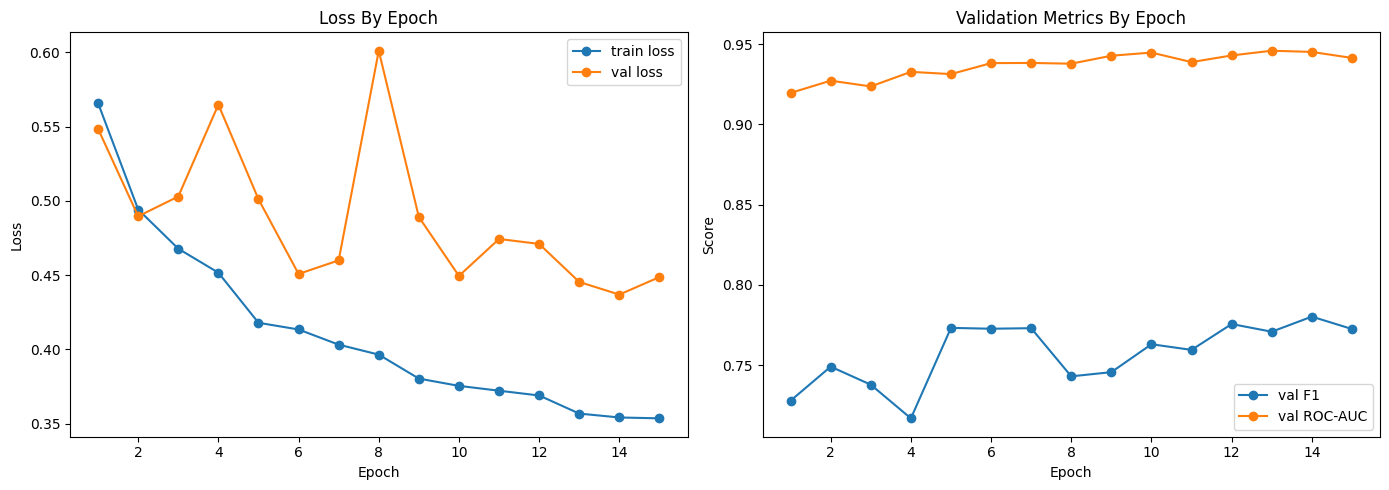

Best validation metrics:


,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,0.445448,0.84425,0.657596,0.931181,0.770833,0.945832,10730,23853,5587,793


Test metrics:


,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,0.422896,0.875519,0.732773,0.890629,0.804026,0.948169,10464,25413,3816,1285


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val loss')
axes[0].set_title('Loss By Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_f1'], marker='o', label='val F1')
axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], marker='o', label='val ROC-AUC')
axes[1].set_title('Validation Metrics By Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Best validation metrics:')
display(pd.DataFrame([metrics_payload['best_val_metrics']]))

print('Test metrics:')
display(pd.DataFrame([metrics_payload['test_metrics']]))


## Outputs

Saved under `PROJECT_ROOT / 'training_runs' / run_name`:

- `best_model.pt`
- `history.csv`
- `metrics.json`
- `config.json`

This notebook uses the cleaned split CSVs from `artifacts/` and does not create new splits.
